# Bangkok District — Mobile/Cellular Speed Analysis

Province-level analysis cuts too coarse for Bangkok.  
This notebook aggregates Ookla **mobile/cellular** tiles to **50 เขต (district)** level.

**District boundary source:** GADM 4.1 Thailand Level 2  
**Speed data:** Ookla Open Data — mobile/cellular (latest available quarter)

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import numpy as np
import os

# Thai font — Sarabun
_font_path = os.path.expanduser('~/.local/share/fonts/Sarabun/Sarabun-Regular.ttf')
fm.fontManager.addfont(_font_path)
_prop = fm.FontProperties(fname=_font_path)
plt.rcParams['font.family'] = _prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

### Config

In [2]:
BKK_DISTRICTS_GEOJSON = '../../data/geo/bangkok_districts.geojson'
OOKLA_RAW_DIR         = '../../data/ookla/raw'
OUTPUT_DIR            = '../../outputs/ookla'

QUARTER = '2025-Q4'  # change to use different quarter
PARQUET  = os.path.join(OOKLA_RAW_DIR, f'{QUARTER}_performance_mobile_tiles.parquet')

METRIC_RAW  = 'avg_d_kbps'
METRIC_MBPS = 'avg_d_mbps'

### Load Bangkok District Boundaries

In [3]:
bkk_gdf = gpd.read_file(BKK_DISTRICTS_GEOJSON).to_crs(4326)
state_bounds = bkk_gdf.total_bounds  # [min_lon, min_lat, max_lon, max_lat]

print(f'Districts loaded: {len(bkk_gdf)}')
print(f'Bangkok bbox: lon {state_bounds[0]:.4f}–{state_bounds[2]:.4f}, lat {state_bounds[1]:.4f}–{state_bounds[3]:.4f}')
bkk_gdf.head()

Districts loaded: 50
Bangkok bbox: lon 100.3200–100.9391, lat 13.4925–13.9543


,gid,name_en,name_th,geometry
0,THA.3.1_1,BangBon,บางบอน,"MULTIPOLYGON (((100.3823 13.6759, 100.3856 13...."
1,THA.3.2_1,BangKapi,บางกะปิ,"MULTIPOLYGON (((100.623 13.8205, 100.6243 13.8..."
2,THA.3.3_1,BangKhae,บางแค,"MULTIPOLYGON (((100.4262 13.6905, 100.3917 13...."
3,THA.3.4_1,BangKhen,บางเขน,"MULTIPOLYGON (((100.6481 13.849, 100.6406 13.8..."
4,THA.3.5_1,BangKhoLaem,บางคอแหลม,"MULTIPOLYGON (((100.497 13.7085, 100.5067 13.7..."


### Load Ookla Mobile Tiles (Bangkok Bbox Only)

In [4]:
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]),
    ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]),
    ('tile_x', '>=', state_bounds[0]),
]

tiles_df = pd.read_parquet(
    PARQUET,
    columns=['tile_x', 'tile_y', 'tests', METRIC_RAW],
    filters=bbox_filters,
)

print(f'Tiles in Bangkok bbox: {len(tiles_df):,}')
tiles_df.head()

Tiles in Bangkok bbox: 6,655


,tile_x,tile_y,tests,avg_d_kbps
0,100.3244,13.9421,1,71878
1,100.3354,13.9527,23,61943
2,100.3409,13.9527,10,219649
3,100.3464,13.9527,5,64785
4,100.3409,13.9474,1,123431


### Create GeoDataFrame from Tile Centroids

In [5]:
tiles_gdf = gpd.GeoDataFrame(
    tiles_df,
    geometry=gpd.points_from_xy(tiles_df.tile_x, tiles_df.tile_y),
    crs='EPSG:4326'
).drop(columns=['tile_x', 'tile_y'])

tiles_gdf.dropna(subset=[METRIC_RAW], inplace=True)
print(f'Valid tiles after dropna: {len(tiles_gdf):,}')

Valid tiles after dropna: 6,655


### Spatial Join — Tiles → Districts

In [6]:
joined = gpd.sjoin(
    tiles_gdf,
    bkk_gdf[['name_en', 'name_th', 'geometry']],
    how='inner',
    predicate='intersects',
)[['name_en', 'name_th', 'tests', METRIC_RAW]]

print(f'Tiles matched to districts: {len(joined):,}')
print(f'Districts covered: {joined["name_en"].nunique()}/50')

Tiles matched to districts: 3,524
Districts covered: 50/50


### Aggregate: Weighted Average per District

In [7]:
district_stats = (
    joined.groupby(['name_en', 'name_th'])
    .apply(
        lambda x: pd.Series({
            METRIC_MBPS: np.average(x[METRIC_RAW], weights=x['tests']) / 1000,
            'total_tests': x['tests'].sum(),
            'n_tiles': len(x),
        }),
        include_groups=False,
    )
    .reset_index()
    .sort_values(METRIC_MBPS, ascending=False)
    .reset_index(drop=True)
)

district_stats['rank'] = district_stats[METRIC_MBPS].rank(ascending=False).astype(int)
print(f'Districts aggregated: {len(district_stats)}')
district_stats.head(10)

Districts aggregated: 50


,name_en,name_th,avg_d_mbps,total_tests,n_tiles,rank
0,PhayaThai,พญาไท,263.790215,2750.0,25.0,1
1,PhraNakhon,พระนคร,216.561746,1310.0,15.0,2
2,BangRak,บางรัก,210.286836,3091.0,13.0,3
3,PathumWan,ปทุมวัน,208.779180,8387.0,25.0,4
4,Dusit,ดุสิต,208.136658,2415.0,33.0,5
5,Samphantawong,สัมพันธวงศ์,199.065276,848.0,6.0,6
6,Wattana,วัฒนา,196.928708,4958.0,38.0,7
7,PomPramSattru,ป้อมปราบศัตรูพ่าย,193.599972,465.0,6.0,8
8,HuaiKwang,ห้วยขวาง,185.054254,5084.0,42.0,9
9,Sathorn,สาทร,182.703786,4037.0,21.0,10


### Top 10 / Bottom 10

In [8]:
top10    = district_stats.head(10)[['rank','name_en','name_th', METRIC_MBPS, 'total_tests']]
bottom10 = district_stats.tail(10)[['rank','name_en','name_th', METRIC_MBPS, 'total_tests']]

print('=== TOP 10 (fastest mobile) ===')
print(top10.to_string(index=False))
print()
print('=== BOTTOM 10 (slowest mobile) ===')
print(bottom10.to_string(index=False))

=== TOP 10 (fastest mobile) ===
 rank       name_en           name_th  avg_d_mbps  total_tests
    1     PhayaThai             พญาไท  263.790215       2750.0
    2    PhraNakhon            พระนคร  216.561746       1310.0
    3       BangRak            บางรัก  210.286836       3091.0
    4     PathumWan           ปทุมวัน  208.779180       8387.0
    5         Dusit             ดุสิต  208.136658       2415.0
    6 Samphantawong       สัมพันธวงศ์  199.065276        848.0
    7       Wattana             วัฒนา  196.928708       4958.0
    8 PomPramSattru ป้อมปราบศัตรูพ่าย  193.599972        465.0
    9     HuaiKwang          ห้วยขวาง  185.054254       5084.0
   10       Sathorn              สาทร  182.703786       4037.0

=== BOTTOM 10 (slowest mobile) ===
 rank      name_en   name_th  avg_d_mbps  total_tests
   41   SaphanSung  สะพานสูง  138.206584       1476.0
   42 ThawiWattana  ทวีวัฒนา  137.539006       1072.0
   43     Thungkru   ทุ่งครุ  135.288710       2355.0
   44        LakSi   หล

### Bar Chart — All 50 Districts Ranked

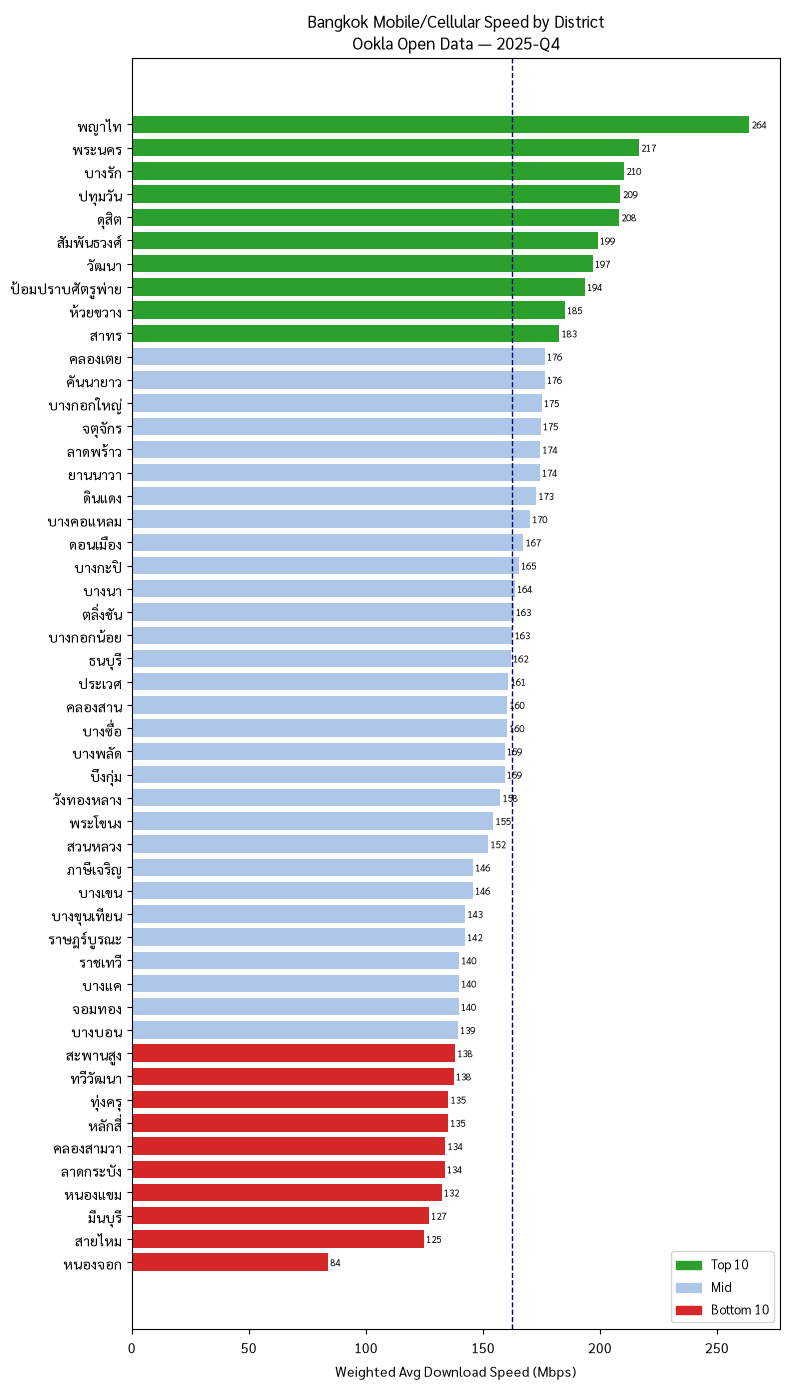

Saved: ../../outputs/ookla/bkk_district_mobile_ranking_2025-Q4.png


In [9]:
df_plot = district_stats.sort_values(METRIC_MBPS, ascending=True)
labels  = df_plot['name_th'].tolist()
values  = df_plot[METRIC_MBPS].tolist()

# Color: top 10 green, bottom 10 red, rest grey
n = len(df_plot)
colors = ['#d62728' if i < 10 else ('#2ca02c' if i >= n - 10 else '#aec7e8') for i in range(n)]

fig, ax = plt.subplots(figsize=(8, 14))
bars = ax.barh(labels, values, color=colors, edgecolor='none', height=0.75)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', ha='left', fontsize=7)

ax.set_xlabel('Weighted Avg Download Speed (Mbps)', fontsize=10)
ax.set_title(f'Bangkok Mobile/Cellular Speed by District\nOokla Open Data — {QUARTER}', fontsize=12)
ax.axvline(district_stats[METRIC_MBPS].mean(), color='navy', linestyle='--', linewidth=1, label='BKK mean')
ax.legend(fontsize=9)

patches = [
    mpatches.Patch(color='#2ca02c', label='Top 10'),
    mpatches.Patch(color='#aec7e8', label='Mid'),
    mpatches.Patch(color='#d62728', label='Bottom 10'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')

plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
out = os.path.join(OUTPUT_DIR, f'bkk_district_mobile_ranking_{QUARTER}.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

### Choropleth Map

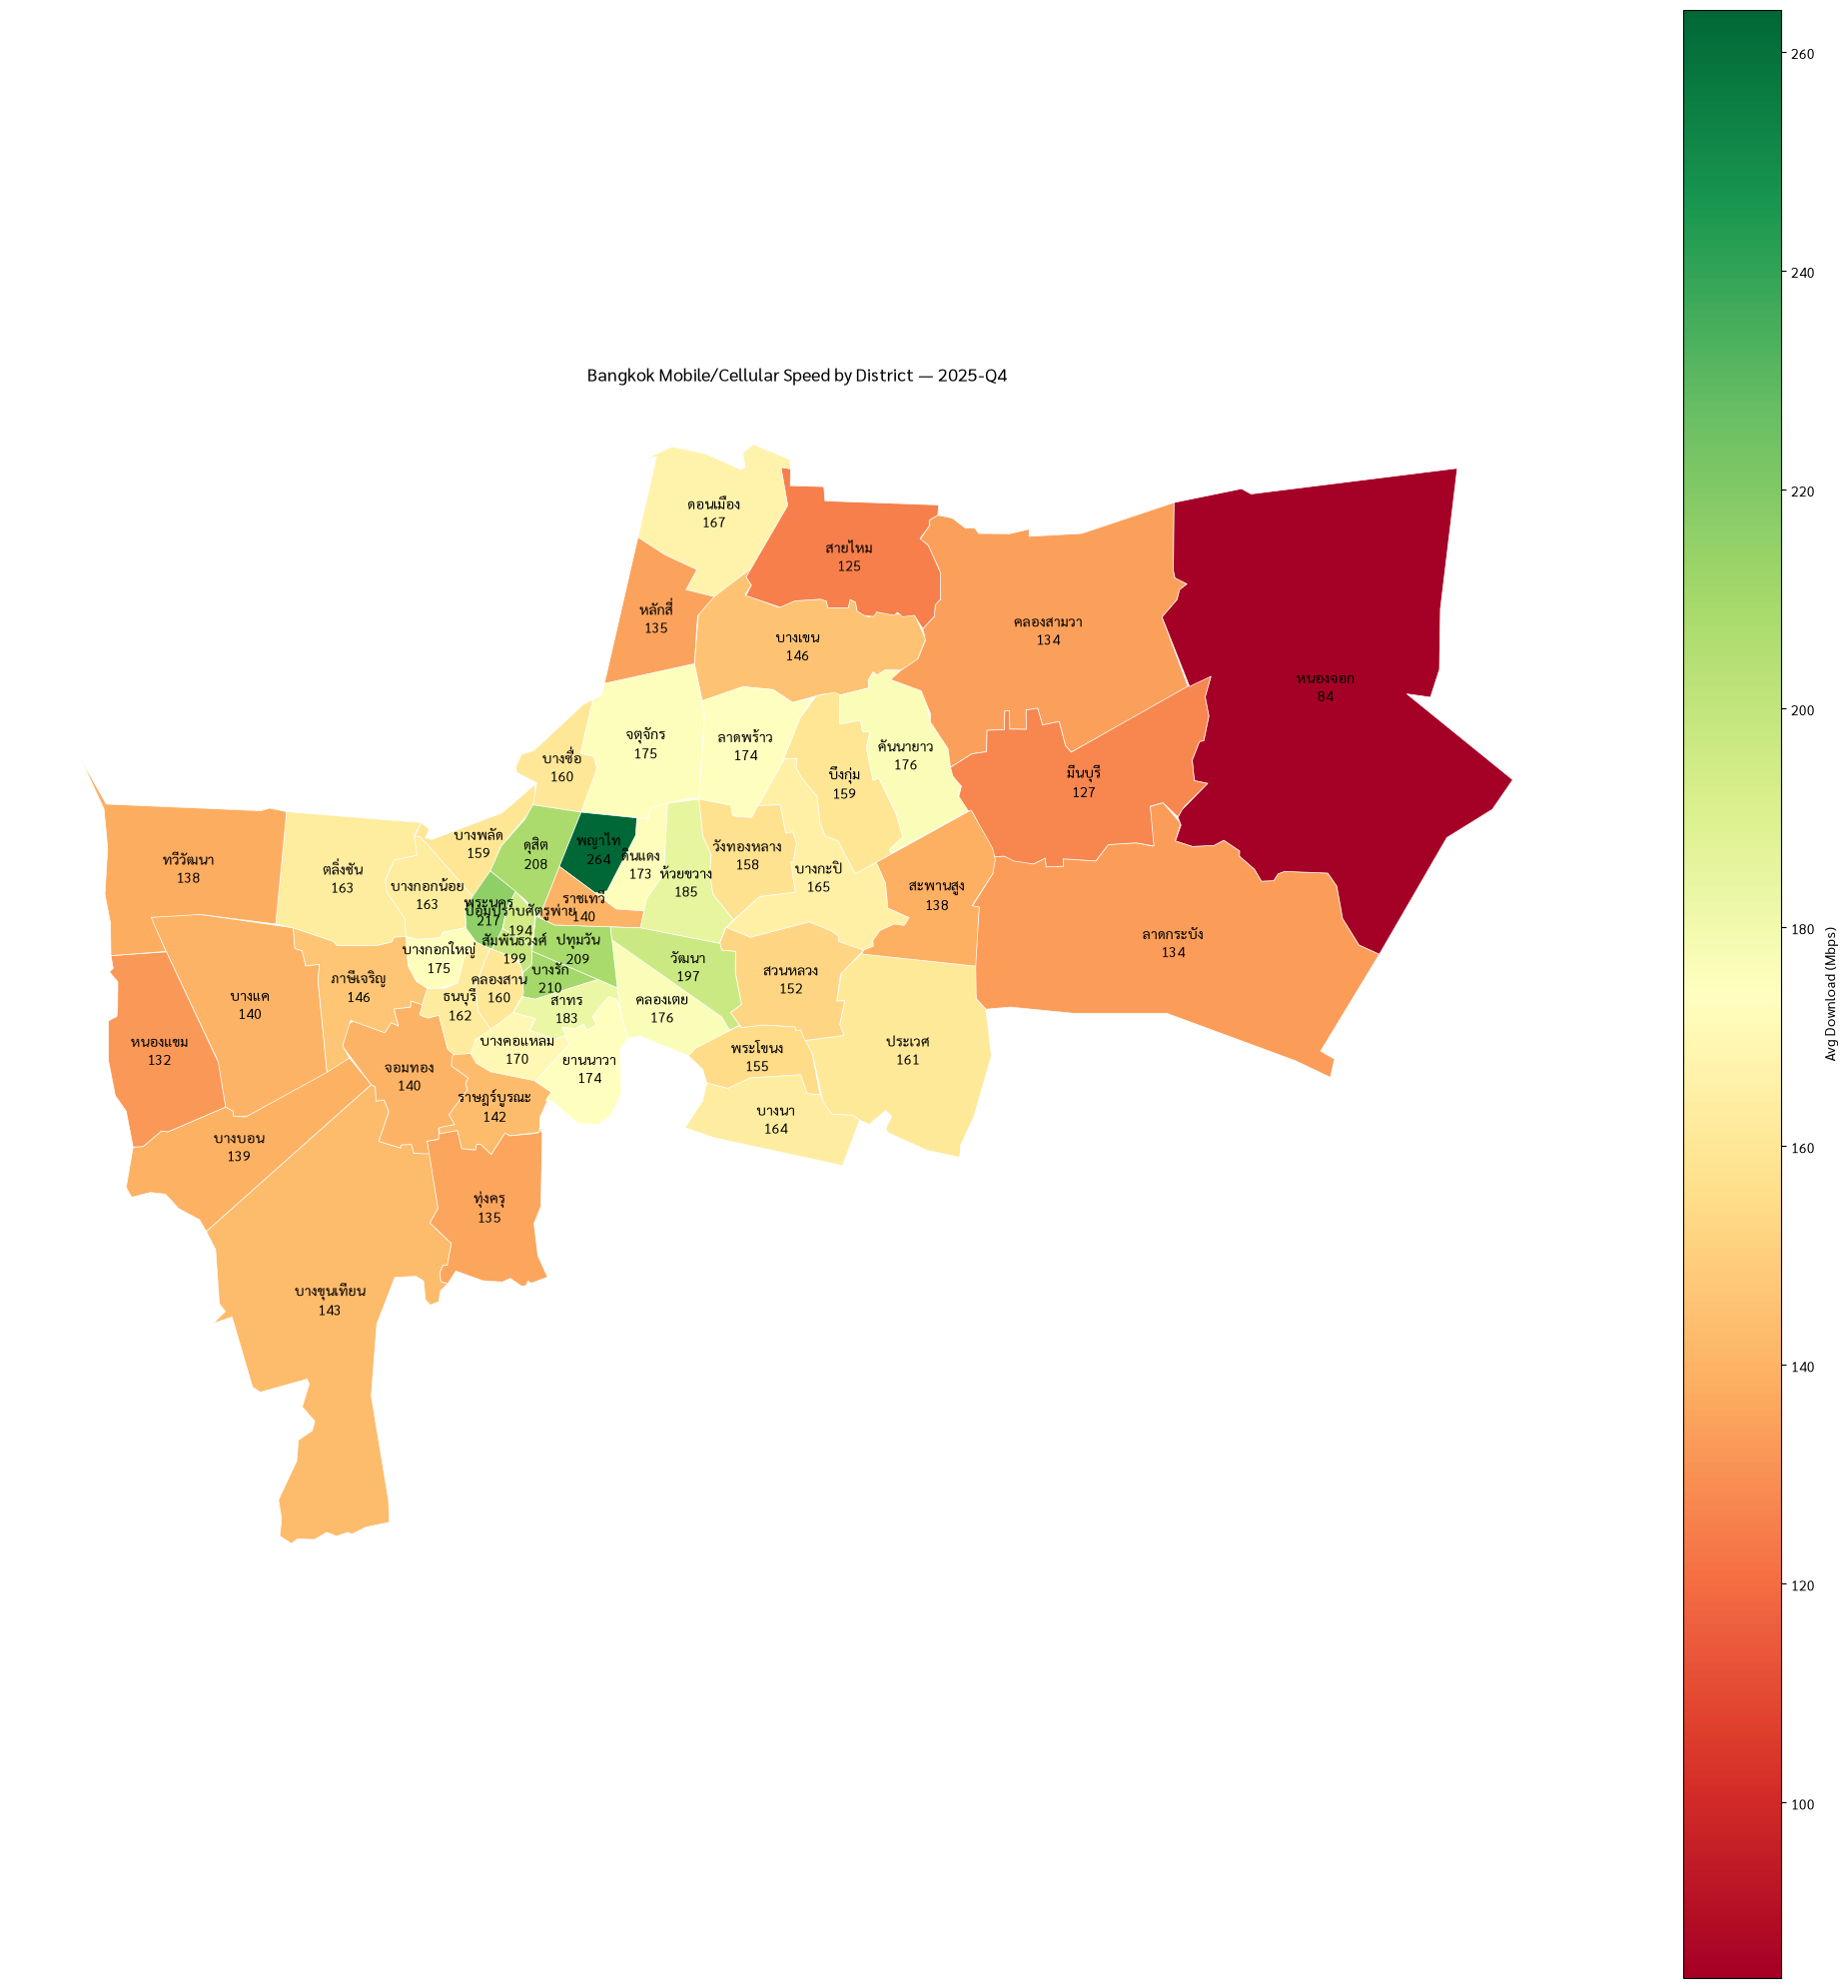

Saved: ../../outputs/ookla/bkk_district_mobile_map_2025-Q4.png


In [10]:
district_geo = bkk_gdf.merge(district_stats, on=['name_en', 'name_th'], how='left')

fig, ax = plt.subplots(1, figsize=(20, 20))
district_geo.plot(
    column=METRIC_MBPS,
    ax=ax,
    cmap='RdYlGn',
    legend=True,
    legend_kwds={'label': 'Avg Download (Mbps)', 'orientation': 'vertical'},
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
)

# Label each district with Thai name + speed
for _, row in district_geo.iterrows():
    if pd.notna(row[METRIC_MBPS]):
        c = row.geometry.centroid
        ax.annotate(
            f"{row['name_th']}\n{row[METRIC_MBPS]:.0f}",
            xy=(c.x, c.y), ha='center', va='center',
            fontsize=10, color='black',
        )

ax.set_title(f'Bangkok Mobile/Cellular Speed by District — {QUARTER}', fontsize=13)
ax.set_axis_off()

plt.tight_layout()
out_map = os.path.join(OUTPUT_DIR, f'bkk_district_mobile_map_{QUARTER}.png')
plt.savefig(out_map, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out_map}')

### Export District Stats CSV

In [11]:
out_csv = os.path.join('../../data/exports', f'bkk_district_mobile_{QUARTER}.csv')
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
district_stats.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')
district_stats

Saved: ../../data/exports/bkk_district_mobile_2025-Q4.csv


,name_en,name_th,avg_d_mbps,total_tests,n_tiles,rank
0,PhayaThai,พญาไท,263.790215,2750.0,25.0,1
1,PhraNakhon,พระนคร,216.561746,1310.0,15.0,2
2,BangRak,บางรัก,210.286836,3091.0,13.0,3
3,PathumWan,ปทุมวัน,208.779180,8387.0,25.0,4
4,Dusit,ดุสิต,208.136658,2415.0,33.0,5
5,Samphantawong,สัมพันธวงศ์,199.065276,848.0,6.0,6
6,Wattana,วัฒนา,196.928708,4958.0,38.0,7
7,PomPramSattru,ป้อมปราบศัตรูพ่าย,193.599972,465.0,6.0,8
8,HuaiKwang,ห้วยขวาง,185.054254,5084.0,42.0,9
9,Sathorn,สาทร,182.703786,4037.0,21.0,10
